In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [11]:
Xc_2, _ = make_classification(n_samples=200,
                              n_features=2,
                              n_informative=2,
                              n_redundant=0,
                              random_state=0,
                              n_clusters_per_class=1,
                              class_sep=0.8)

### Ініціалізація

In [ ]:
def init_centroids_random(X, K, rng):
    m = X.shape[0]
    indices = rng.choice(m, size=K, replace=False)
    return X[indices].copy()

In [ ]:
def assign_clusters(X, centroids):
    diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    dists = np.linalg.norm(diff, axis=2)
    labels = np.argmin(dists, axis=1)
    min_dists = dists[np.arange(X.shape[0]), labels]
    return labels, min_dists

### Обчислення середніх координад для кожного кластера

In [15]:
def compute_centroids(X, labels, K, rng):
    d = X.shape[1]
    centroids = np.zeros((K, d))
    for k in range(K):
        members = X[labels == k]
        if members.shape[0] == 0:
            centroids[k] = X[rng.integers(0, X.shape[0])]
        else:
            centroids[k] = members.mean(axis=0)
    return centroids

def compute_cost_from_dists(min_dists):
    """J = (1/m) * sum (d_i)^2"""
    return np.mean(min_dists ** 2)

### Ітерації

In [16]:
def kmeans_single_run(X, K, rng, max_iter=200, tol=1e-5, verbose=False):
    """
    Один запуск K-means з випадковою ініціалізацією.
    Повертає словник з полями:
      centroids, labels, costs_history (list), final_cost, iters
    """
    centroids = init_centroids_random(X, K, rng)
    costs_history = []
    for it in range(max_iter):
        labels, min_dists = assign_clusters(X, centroids)
        cost = compute_cost_from_dists(min_dists)
        costs_history.append(cost)
        new_centroids = compute_centroids(X, labels, K, rng)
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if verbose:
            print(f"Iter {it+1}: cost={cost:.6f}, centroid shift={shift:.6f}")
        if shift < tol:
            break
    # final assignment to ensure consistency
    labels, min_dists = assign_clusters(X, centroids)
    final_cost = compute_cost_from_dists(min_dists)
    return {
        "centroids": centroids,
        "labels": labels,
        "costs_history": costs_history,
        "final_cost": final_cost,
        "iters": len(costs_history)
    }

### Запуск

In [17]:
def run_kmeans_multiple_inits(X, K, n_init=100, seed=None, max_iter=200, tol=1e-5, verbose=False):
    """
    Запустити kmeans_single_run n_init разів з різними RNG.
    Повертає best_result (з найменшим final_cost) і список всіх результатів.
    """
    rng_master = np.random.default_rng(seed)
    best_result = None
    best_cost = np.inf
    all_results = []
    for i in range(n_init):
        rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))
        res = kmeans_single_run(X, K, rng, max_iter=max_iter, tol=tol, verbose=False)
        all_results.append(res)
        if res["final_cost"] < best_cost:
            best_cost = res["final_cost"]
            best_result = res
        if verbose and (i+1) % 10 == 0:
            print(f"Init {i+1}/{n_init}, current best cost={best_cost:.6f}")
    return best_result, all_results

In [18]:
K = 4
n_init = 100
seed = 42

best_res, all_res = run_kmeans_multiple_inits(Xc_2, K, n_init=n_init, seed=seed, max_iter=200, tol=1e-5, verbose=True)
print(f"Best final cost J = {best_res['final_cost']:.6f}, iterations in best run = {best_res['iters']}")

Init 10/100, current best cost=0.457692
Init 20/100, current best cost=0.457692
Init 30/100, current best cost=0.457692
Init 40/100, current best cost=0.457692
Init 50/100, current best cost=0.457692
Init 60/100, current best cost=0.457692
Init 70/100, current best cost=0.457692
Init 80/100, current best cost=0.457692
Init 90/100, current best cost=0.457692
Init 100/100, current best cost=0.457692
Best final cost J = 0.457692, iterations in best run = 13


### Візуалізація

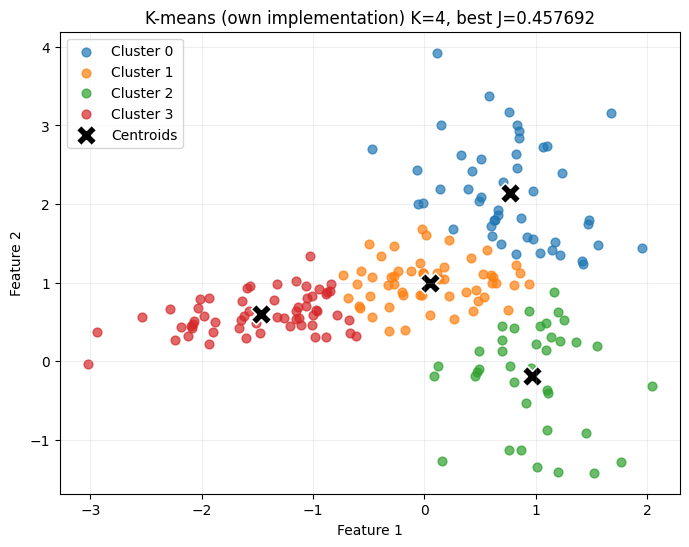

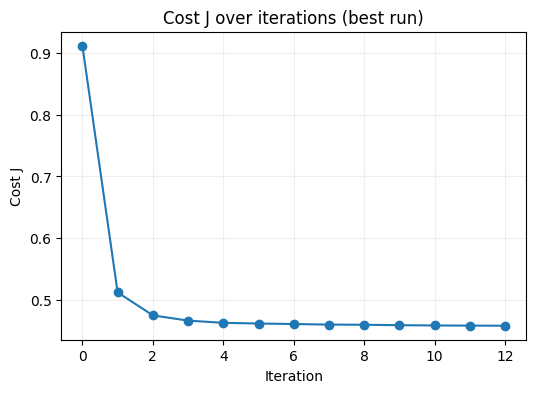

In [19]:
plt.figure(figsize=(8,6))
colors = plt.cm.tab10(np.arange(K) % 10)
for k in range(K):
    pts = Xc_2[labels == k]
    plt.scatter(pts[:,0], pts[:,1], s=40, color=colors[k], label=f"Cluster {k}", alpha=0.7)
plt.scatter(centroids[:,0], centroids[:,1], s=220, color='black', marker='X', edgecolor='white', linewidth=1.2, label='Centroids')
plt.title(f"K-means (own implementation) K={K}, best J={best_res['final_cost']:.6f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(best_res["costs_history"], marker='o')
plt.title("Cost J over iterations (best run)")
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.grid(alpha=0.2)
plt.show()